# Cosmological subhalos: from a dark matter model to stream perturbations

Two halves.

**Sections 1-3 — the survival calculation.** How many more (or fewer) subhalos survive
tidal stripping when the infall mass-concentration relation is scaled by `c_scale`,
relative to pyHalo CDM. The answer is a single **amplitude** multiplying the subhalo
number density.

**Section 4 — the pipeline.** A `DarkMatterModel` in, a catalog of impactors out, ready
for `ImpactGenerator` and the perturbation machinery.

Contents:

1. Amplitude vs. `c_scale`, and the power-law fit
2. Bound mass functions, against `M^-1.9`
3. Validation of the vectorized tidal model against native pyHalo calls
4. End-to-end: dark matter model $\rightarrow$ impact rates $\rightarrow$ impactor catalog

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from streamsculptor.cosmological import InfallPopulation

PALETTE = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"]
INK, MUTED = "#1a1a1a", "#8a8a8a"

## 1. Amplitude vs. concentration scaling

`InfallPopulation` is the raw pyHalo draw, tidally evolved on demand. It knows nothing
about `c_scale`: the concentration scaling is applied when `f_bound` is evaluated, so one
draw serves every scaling and all of them share common random numbers. That is what makes
`amplitude(1.0) == 1.0` exactly rather than 1 plus Monte Carlo noise.

The bound-mass window is the range we actually simulate impacts for, `1e5` to `2e8` Msun.
The infall draw runs far below it, since median `f_bound` inside 30 kpc is only a few
times `1e-3`.

In [2]:
WINDOW = (5.0, float(np.log10(2e8)))     # bound-mass window [log10 Msun]

pop = InfallPopulation(
    slope=-1.9,
    log10M_infall_range=(4.0, 11.0),
    N=150_000,
    seed=1,
)

c_scales = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 8.0])
amps = np.array([pop.amplitude(c, WINDOW) for c in c_scales])

print("c_scale   amplitude")
for c, a in zip(c_scales, amps):
    print(f"  {c:4.2f}      {a:.3f}")

c_scale   amplitude
  0.50      0.490
  0.75      0.754
  1.00      1.000
  1.25      1.229
  1.50      1.450
  2.00      1.841
  3.00      2.512
  5.00      3.517
  8.00      4.428


best-fit exponent p = 0.781
max fractional residual from the power law: 0.158


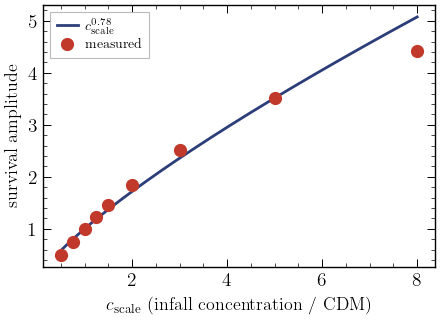

In [3]:
# Power-law fit: amplitude = c_scale ** p, forced through (1, 1)
p = np.sum(np.log(c_scales) * np.log(amps)) / np.sum(np.log(c_scales) ** 2)
print(f"best-fit exponent p = {p:.3f}")

cc = np.logspace(np.log10(c_scales.min()), np.log10(c_scales.max()), 200)

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.plot(cc, cc**p, lw=2, label=f"$c_{{\\rm scale}}^{{{p:.2f}}}$", zorder=2)
ax.plot(c_scales, amps, "o", ms=8, mew=1.5,
        label="measured", zorder=3)


#ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$c_{\rm scale}$  (infall concentration / CDM)")
ax.set_ylabel("survival amplitude")
#ax.set_title("Surviving subhalos, $10^5$–$2{\\times}10^8\\,M_\\odot$ bound", color=INK, fontsize=9)

ax.legend()
fig.tight_layout()

resid = amps / c_scales**p - 1
print(f"max fractional residual from the power law: {np.abs(resid).max():.3f}")

## 2. Bound mass functions

Weighted by the SHMF importance weights, so these are `dN/dlog10 M_bound` up to a
common normalisation. The dashed line is the `dN/dM ~ M^-1.9` input slope
(`dN/dlog10 M ~ M^-0.9`), normalised to the CDM curve at `1e6` Msun.

The shaded band marks the bound-mass window the amplitude is counted over.

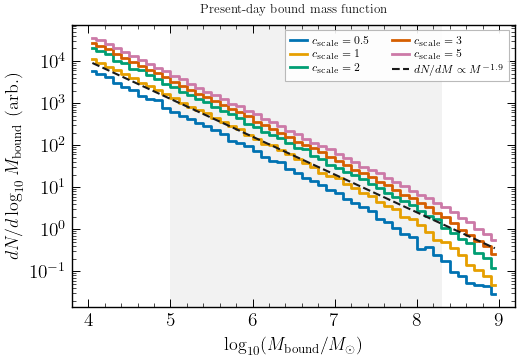

In [4]:
show_scales = [0.5, 1.0, 2.0, 3.0, 5.0, 8.0]
bins = np.linspace(4.0, 9.0, 51)
centers = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots(figsize=(5.4, 3.8))

curves = {}
for c, color in zip(show_scales, PALETTE):
    m_bound = pop.m_bound(c)
    ok = m_bound > 0
    sw, _ = np.histogram(np.log10(m_bound[ok]), bins=bins, weights=pop.weights[ok])
    dN = sw / np.diff(bins)
    curves[c] = dN
    ax.step(centers, dN, where="mid", lw=2, color=color,
            label=f"$c_{{\\rm scale}}={c:g}$")

# M^-1.9 reference, anchored to CDM at 1e6
anchor = np.argmin(np.abs(centers - 6.0))
ref = 10.0 ** (-0.9 * (centers - centers[anchor])) * curves[1.0][anchor]
ax.plot(centers, ref, ls="--", lw=1.5, color=INK, label=r"$dN/dM \propto M^{-1.9}$")

ax.axvspan(*WINDOW, color="#000000", alpha=0.05, lw=0, zorder=0)

ax.set_yscale("log")
ax.set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
ax.set_ylabel(r"$dN/d\log_{10}M_{\rm bound}$  (arb.)")
ax.set_title("Present-day bound mass function", color=INK, fontsize=9)

ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

## 3. Validating the vectorized tidal model

`InfallPopulation` does not call `InterpGalacticusMW.__call__`. That method ends in
`johnsonsu.rvs(a, b)` — an unseeded draw, so it returns a different answer every call
and a CDM-vs-CDM ratio would not come out to 1. Instead we call the underlying
`_a_interp`/`_b_interp` directly and evaluate `johnsonsu.ppf(u, a, b)` at frozen
uniforms `u`.

Two checks:

- **Exact:** the interpolated Johnson-SU parameters `(a, b)` match native pyHalo
  halo-by-halo, including the clipping at the edges of the calibration grid.
- **Distributional:** the resulting `log10 f_bound` values are drawn from the same
  distribution as many native stochastic calls (two-sample KS test).

In [5]:
from scipy.stats import ks_2samp, johnsonsu

rng = np.random.default_rng(0)
idx = rng.choice(len(pop.m_infall), 2000, replace=False)
c_test = 8.0  # deliberately extreme: pushes ~4% of halos past the c=128 grid edge,
              # so the concentration clipping path is exercised, not assumed.
              # (The t_since_infall clip at 12.9 Gyr is always exercised: the
              #  population reaches 13.5 Gyr.)

c_vals = c_test * pop.c_cdm[idx]
t_vals = pop.t_since_infall[idx]

# --- native pyHalo parameter lookup, one halo at a time (its own clipping) ---
a_native, b_native = np.empty(len(idx)), np.empty(len(idx))
for i, (cv, tv) in enumerate(zip(c_vals, t_vals)):
    lc = min(max(np.log10(cv), np.log10(2)), np.log10(128))
    tt = min(max(tv, 0.0), 12.9)
    ch = min(max(pop.chost, 6.0), 12.0)
    pnt = (tt, lc, ch)
    a_native[i] = pop._tidal._a_interp(pnt)
    b_native[i] = pop._tidal._b_interp(pnt)

# --- vectorized path, exactly as InfallPopulation.f_bound builds it ---
lc_v = np.clip(np.log10(c_vals), np.log10(2.0), np.log10(128.0))
tt_v = np.clip(t_vals, 0.0, 12.9)
pts = np.column_stack([tt_v, lc_v, np.full_like(tt_v, np.clip(pop.chost, 6.0, 12.0))])
a_vec, b_vec = pop._tidal._a_interp(pts), pop._tidal._b_interp(pts)

print(f"max |a_vec - a_native| = {np.abs(a_vec - a_native).max():.3e}")
print(f"max |b_vec - b_native| = {np.abs(b_vec - b_native).max():.3e}")
print(f"fraction clipped in concentration = "
      f"{np.mean((c_vals > 128) | (c_vals < 2)):.3f}")
print(f"fraction clipped in time          = {np.mean(t_vals > 12.9):.3f}")

max |a_vec - a_native| = 0.000e+00
max |b_vec - b_native| = 0.000e+00
fraction clipped in concentration = 0.040
fraction clipped in time          = 0.098


KS statistic = 0.0260,  p = 0.509
native  median -1.019   mean -1.161
ours    median -1.022   mean -1.185


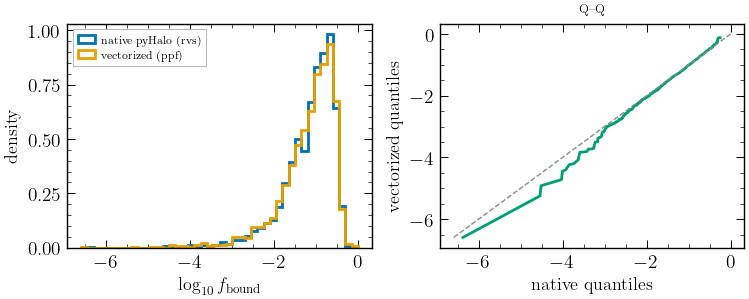

In [6]:
# Distributional check: native stochastic calls vs. our frozen-quantile values.
native = np.array([
    pop._tidal(np.log10(cv), tv, pop.chost)
    for cv, tv in zip(c_vals, t_vals)
])

ours = np.minimum(johnsonsu.ppf(pop.u_scatter[idx], a_vec, b_vec), 0.0)

ks = ks_2samp(native, ours)
print(f"KS statistic = {ks.statistic:.4f},  p = {ks.pvalue:.3f}")
print(f"native  median {np.median(native):+.3f}   mean {native.mean():+.3f}")
print(f"ours    median {np.median(ours):+.3f}   mean {ours.mean():+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))

hb = np.linspace(min(native.min(), ours.min()), 0.0, 45)
axes[0].hist(native, bins=hb, histtype="step", lw=2, color=PALETTE[0],
             density=True, label="native pyHalo (rvs)")
axes[0].hist(ours, bins=hb, histtype="step", lw=2, color=PALETTE[1],
             density=True, label="vectorized (ppf)")
axes[0].set_xlabel(r"$\log_{10} f_{\rm bound}$")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8)

xs = np.sort(native); ys = np.sort(ours)
axes[1].plot(xs, ys, lw=2, color=PALETTE[2])
lim = [min(xs[0], ys[0]), 0.0]
axes[1].plot(lim, lim, ls="--", lw=1, color=MUTED)
axes[1].set_xlabel("native quantiles")
axes[1].set_ylabel("vectorized quantiles")
axes[1].set_title("Q–Q", color=INK, fontsize=9)

 
fig.tight_layout()

In [7]:
# End-to-end: the amplitude itself, computed the slow native way on a subsample.
# Native calls are stochastic, so this is a noisy estimate -- repeat it a few times
# to see the scatter the frozen-quantile version removes.
sub = rng.choice(len(pop.m_infall), 20_000, replace=False)
lo, hi = WINDOW

def native_amplitude(c_scale):
    out = {}
    for cs in (1.0, c_scale):
        f = np.array([
            10 ** pop._tidal(np.log10(cs * pop.c_cdm[i]), pop.t_since_infall[i], pop.chost)
            for i in sub
        ])
        mb = pop.m_infall[sub] * np.clip(f, 0.0, 1.0)
        inside = (mb >= 10**lo) & (mb <= 10**hi)
        out[cs] = pop.weights[sub][inside].sum()
    return out[c_scale] / out[1.0]

trials = [native_amplitude(2.0) for _ in range(3)]
print("native  amplitude(2.0), 3 independent trials:",
      ", ".join(f"{t:.3f}" for t in trials))
print(f"vectorized amplitude(2.0):                  {pop.amplitude(2.0, WINDOW):.3f}")

native  amplitude(2.0), 3 independent trials: 1.790, 1.794, 1.784
vectorized amplitude(2.0):                  1.841


---

# 4. End-to-end: dark matter model $\rightarrow$ impactor catalog

Sections 1-3 measure how subhalo *survival* responds to the infall mass-concentration
relation. This section puts that to work.

The whole pipeline is four objects:

| object | holds | cost |
|---|---|---|
| `DarkMatterModel` | `c_scale`, `slope`, `normalization`, `M_hm` | free |
| `SubhaloPopulation` | the pyHalo draw under that model | one draw per `slope` |
| `CrossSection` | `b_max(M)` | free |
| `ImpactRates` | the stream's orbit; wraps `RateCalculator` | one orbit integration |

The dark matter model appears **only** in `DarkMatterModel`. Nothing downstream takes
`c_scale` or `slope`, so the two halves of the calculation — how many impacts, and what
the impactors are — cannot describe different universes.

`ImpactRates` does not own the stream. It gives you a number of impacts and their
properties; placing them on the stream is `ImpactGenerator`'s job, in 4.6.

In [8]:
import jax
import jax.numpy as jnp
from astropy import units as u
import diffrax

jax.config.update("jax_enable_x64", True)

import streamsculptor as ssc
from streamsculptor import potential
from streamsculptor import JaxCoords as jc
from streamsculptor.main import usys

from streamsculptor.cosmological import (
    DarkMatterModel, SubhaloPopulation, KickCrossSection, ScaleRadiusCrossSection,
    ImpactRates, PowerLawAmplitude,
)
from streamsculptor.GenerateImpactParams import ImpactGenerator

## 4.1 Stream setup

A GD-1-like stream in the Gala Milky Way potential. Identical to the setup in
`rate_calculator.ipynb` — see that notebook for the coordinate transform details.

In [9]:
@jax.jit
def icrs_to_gd1(ra_rad, dec_rad):
    # Differentiable ICRS -> GD-1 (phi1, phi2); rotation matrix from Koposov+2010
    R = jnp.array([[-0.4776303088, -0.1738432154, 0.8611897727],
                   [0.510844589, -0.8524449229, 0.111245042],
                   [0.7147776536, 0.4930681392, 0.4959603976]])
    icrs_vec = jnp.vstack([jnp.cos(ra_rad) * jnp.cos(dec_rad),
                           jnp.sin(ra_rad) * jnp.cos(dec_rad),
                           jnp.sin(dec_rad)]).T
    v = jnp.einsum("ij,kj->ki", R, icrs_vec)
    return (jnp.arctan2(v[:, 1], v[:, 0]) * 180 / jnp.pi,
            jnp.arcsin(v[:, 2]) * 180 / jnp.pi)

@jax.jit
def get_phi12_from_stream(stream):
    ra, dec, _ = jax.vmap(jc.simcart_to_icrs)(stream[:, :3])
    return icrs_to_gd1(ra * jnp.pi / 180, dec * jnp.pi / 180)

In [10]:
prog = jnp.load("../data/GD1_prog/GD1_progenitor.npy", allow_pickle=True).item()
prog_wtoday = jnp.hstack([prog.pos.xyz.to(u.kpc).value,
                          prog.vel.d_xyz.to(u.kpc / u.Myr).value])

pot = potential.GalaMilkyWayPotential(units=usys)
t_age = 2500.0        # stream age [Myr]
t_dissolve = -300.0   # stripping stops here [Myr]

IC = pot.integrate_orbit(w0=prog_wtoday, t0=0.0, t1=-t_age,
                         ts=jnp.array([-t_age])).ys[0]
ts = jnp.hstack([jnp.linspace(-t_age, t_dissolve, 2_000), jnp.array([0.0])])

lead, trail = pot.gen_stream_scan(prog_w0=IC, ts=ts, seed_num=532, Msat=1e4,
                                  atol=1e-6, rtol=1e-6, solver=diffrax.Dopri5())
stream = jnp.vstack([lead, trail])
phi1_model, phi2_model = get_phi12_from_stream(stream)

l_obs = ssc.compute_stream_length(stream=stream, phi1=phi1_model)
tsave = jnp.linspace(-t_age, 0.0, 500)
prog_orb = pot.integrate_orbit(w0=IC, t0=-t_age, t1=0.0, ts=tsave)

print(f"stream length today = {float(l_obs):.1f} kpc")

stream length today = 21.0 kpc


## 4.2 Dark matter models

Each knob acts in a different place, and the model is what keeps them in step:

- `c_scale` — the infall MCR. Moves the survival amplitude (how many subhalos) *and*
  the impactor structure (how compact they are).
- `slope` — the SHMF, `dN/dM ~ M**slope`. Sets the Erkal mass function in the rate *and*
  the importance weights of the pyHalo population. Getting these two out of step is the
  easy mistake, and it is why the model owns the population.
- `normalization` — a multiplier on the rate. Changes how many impacts, not which.
- `M_hm` — WDM suppression of the mass function. `0` is CDM.

Only `slope` forces a new pyHalo draw. Populations are cached, so scanning `c_scale`
is free.

In [11]:
MODELS = [
    DarkMatterModel(name="CDM"),
    DarkMatterModel(c_scale=2.0, name="compact (c x 2)"),
    DarkMatterModel(slope=-1.7, name="shallow SHMF"),
    DarkMatterModel(normalization=0.5, name="half normalization"),
]

COLORS = {m.name: c for m, c in zip(MODELS, PALETTE)}

## 4.3 Population, cross-section, rates

`KickCrossSection` sets `b_max` by the faintest velocity kick worth simulating, in the
point-mass impulse limit:

$$b_{\rm max}(M) = \min\left(\frac{2GM}{v_{\rm char}\,\Delta v_{\rm min}},\ b_{\rm ceiling}\right)$$

Deliberately *not* a multiple of the scale radius: tying `b_max` to $r_s$ shrinks the
sampling volume for compact subhalos at the same moment the survival amplitude says there
are more of them, two concentration effects with opposite signs partly cancelling for no
physical reason. Here concentration moves the amplitude and nothing else.

`dV_min` is a convergence knob, not a physical parameter — the rate scales as
$1/\Delta v_{\rm min}$, so scan it and check your summary statistic plateaus.

Building `ImpactRates` once and calling `.with_model()` reuses both the orbit and the
cached pyHalo draw.

In [12]:
xsec = KickCrossSection(v_char=50.0, dV_min=0.05, b_ceiling=8.0)

population = SubhaloPopulation(MODELS[0], log10M_bound_range=WINDOW,
                               log10M_infall_range=(4.0, 11.0), N=150_000, seed=1)

rates = ImpactRates(population, xsec,
                    orbit=prog_orb, t_age=t_age, l_obs=l_obs,
                    prog_today=prog_wtoday, first_strip_lead=lead[0],
                    first_strip_trail=trail[0], pot=pot)

# All four supplied -> stream-length oscillations, so linear_growth is off by default.
print(f"linear_growth = {rates.linear_growth}")
print(f"b_max hits its ceiling above {xsec.m_ceiling:.2e} Msun")

model_rates = {m.name: rates.with_model(m) for m in MODELS}

print(f"\n{'model':20s} {'amplitude':>10s} {'<N_impacts>':>12s}")
for m in MODELS:
    r = model_rates[m.name]
    print(f"{m.name:20s} {r.amplitude:10.3f} {r.expected_impacts():12.2f}")

linear_growth = False
b_max hits its ceiling above 2.33e+06 Msun



model                 amplitude  <N_impacts>


CDM                       1.000       127.87


compact (c x 2)           1.841       235.39


shallow SHMF              1.000        71.25


half normalization        1.000        63.93


The amplitude here is computed exactly from the population. For a differentiable or
jitted amplitude, opt in to the power-law fit from section 1 — and note it is a ~7 percent
approximation at `c_scale = 2`, which is why it is not the default.

In [13]:
exact = rates.with_model(DarkMatterModel(c_scale=2.0))
fitted = rates.with_model(DarkMatterModel(c_scale=2.0,
                                          amplitude_model=PowerLawAmplitude(exponent=p)))
print(f"exact amplitude      {exact.amplitude:.4f}")
print(f"power-law amplitude  {fitted.amplitude:.4f}   "
      f"({100*(fitted.amplitude/exact.amplitude - 1):+.1f} %)")

exact amplitude      1.8409


power-law amplitude  1.7184   (-6.7 %)


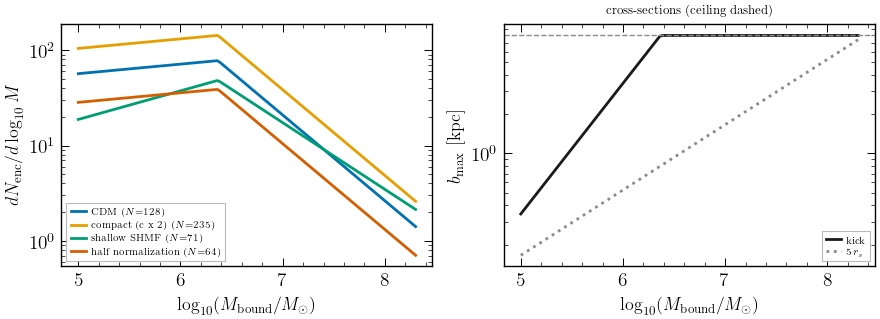

In [14]:
log10M_grid = jnp.linspace(*WINDOW, 120)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.4))

for m in MODELS:
    r = model_rates[m.name]
    axes[0].plot(log10M_grid, r.dN_dlog10M(log10M_grid), lw=2, color=COLORS[m.name],
                 label=f"{m.name}  ($N$={r.expected_impacts():.0f})")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
axes[0].set_ylabel(r"$dN_{\rm enc}/d\log_{10}M$")
axes[0].legend(fontsize=7)

axes[1].plot(log10M_grid, xsec(log10M_grid), lw=2, color=INK, label="kick")
axes[1].plot(log10M_grid, ScaleRadiusCrossSection(b_max_fac=5.0)(log10M_grid),
             lw=2, ls=":", color=MUTED, label=r"$5\,r_s$")
axes[1].axhline(float(xsec.b_ceiling), ls="--", lw=1, color=MUTED)
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
axes[1].set_ylabel(r"$b_{\rm max}$ [kpc]")
axes[1].legend(fontsize=7)
axes[1].set_title("cross-sections (ceiling dashed)", fontsize=9)


fig.tight_layout()

Because $b_{\rm max} \propto M$ while $dN/d\log_{10}M \propto M^{-0.9}$, the encounter
count runs as $M^{0.1}$ — nearly flat per decade until `b_ceiling` bites, then falling as
$M^{-0.9}$. Most impacts are therefore *not* low-mass. Swapping in
`ScaleRadiusCrossSection` gives $b_{\rm max} \propto M^{0.5}$ and hence
$M^{-0.4}$ — monotonically falling, with no break. The two are not small perturbations on
each other, so a rate is only meaningful alongside its cross-section.

## 4.4 The impactor catalog

`sample_impactors` does the Poisson draw and the resampling in one call. Each impactor is
an actual member of the tidally evolved population, so its bound mass and its TNFW
parameters `(rhos, rs, ft, rt)` describe the same halo — no mass-matching tolerance
anywhere.

In [15]:
key = jax.random.PRNGKey(3)

catalogs = {m.name: model_rates[m.name].sample_impactors(key, seed=7) for m in MODELS}

for m in MODELS:
    print(f"{m.name:20s} {catalogs[m.name].summary()}")

CDM                  N=107  median M_bound=8.29e+05  f(>1e7)=0.084  median r_s=0.206 kpc
compact (c x 2)      N=207  median M_bound=8.40e+05  f(>1e7)=0.058  median r_s=0.109 kpc
shallow SHMF         N=55  median M_bound=1.38e+06  f(>1e7)=0.073  median r_s=0.361 kpc
half normalization   N=49  median M_bound=7.78e+05  f(>1e7)=0.061  median r_s=0.194 kpc


In [16]:
# What a catalog contains, first few impactors of the CDM realization.
cat = catalogs["CDM"]
print("  ".join(f"{k:>10s}" for k in cat.keys()))
for i in range(6):
    print("  ".join(f"{cat[k][i]:10.3g}" for k in cat.keys()))

   m_bound    m_infall    c_infall    z_infall  t_since_infall     f_bound        rhos          rs          ft          rt       b_max
  2.33e+06    5.79e+07        6.82        2.53        11.2      0.0402    3.27e+07       0.492       0.624       0.155           8
  3.74e+05    8.52e+05        11.8        1.83        10.2        0.44    6.57e+07      0.0859       0.924       0.274        1.29
  1.11e+07    2.18e+08        10.9        1.07        8.18       0.051     2.4e+07       0.775       0.684       0.342           8
  1.12e+05    5.37e+06        4.08        3.83        12.2       0.021    2.52e+07       0.274       0.513      0.0468       0.387
  1.36e+08    7.27e+08         9.7       0.657        6.21       0.187    1.11e+07        1.53       0.827        1.77           8
  3.26e+06    6.48e+07        8.34        1.95        10.4      0.0502     3.2e+07       0.493       0.665       0.195           8


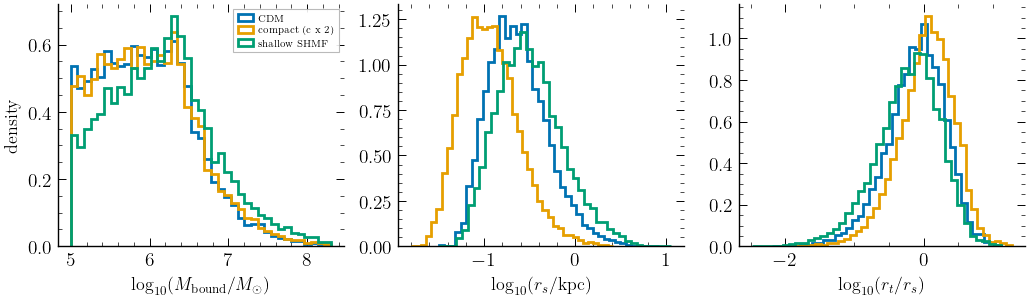

In [17]:
# Impactor properties. Only models with a distinct (c_scale, slope) appear: normalization
# scales the rate and never reaches the resampling, so "half normalization" draws a
# bit-identical catalog to CDM and would simply overplot it.
distinct, seen = [], set()
for m in MODELS:
    if (m.c_scale, m.slope) not in seen:
        seen.add((m.c_scale, m.slope))
        distinct.append(m)

# n_impacts overrides the Poisson draw: we want the distribution, not one realization.
big = {m.name: model_rates[m.name].sample_impactors(key, seed=11, n_impacts=30_000)
       for m in distinct}

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))

bins_m = np.linspace(*WINDOW, 40)
for m in distinct:
    axes[0].hist(np.log10(big[m.name]["m_bound"]), bins=bins_m, histtype="step",
                 lw=2, density=True, color=COLORS[m.name], label=m.name)
axes[0].set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
axes[0].set_ylabel("density")
axes[0].legend(fontsize=7)

for m in distinct:
    axes[1].hist(np.log10(big[m.name]["rs"]), bins=40, histtype="step", lw=2,
                 density=True, color=COLORS[m.name])
axes[1].set_xlabel(r"$\log_{10}(r_s/{\rm kpc})$")

# r_t alone is nearly independent of c_scale at fixed bound mass: the Du+2024 track sets
# r_t in units of the infall virial radius, and a denser halo reaching the same M_bound
# fell in slightly lighter (smaller R200) with a larger f_bound -- the two cancel.
# Compactness shows up in r_t/r_s, since r_s itself halves.
for m in distinct:
    axes[2].hist(np.log10(big[m.name]["rt"] / big[m.name]["rs"]), bins=40,
                 histtype="step", lw=2, density=True, color=COLORS[m.name])
axes[2].set_xlabel(r"$\log_{10}(r_t/r_s)$")

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()

## 4.5 Validating the resampling

Impactors are **not** a fair sample of the population. The encounter rate weights by
cross-section, and since the radial profile factorises out of $dn/d\log_{10}M$, the only
mass-dependent weight is $b_{\rm max}(M)$:

$$p(\text{impactor} = \text{halo } i) \propto w_i\, b_{\rm max}(M_i)$$

Two checks:

**(a) The weight is not optional.** `SubhaloPopulation.resample` without a `weight_fn` is
a fair draw from the population's own mass function — which is the wrong distribution for
impactors.

**(b) The weighted draw reproduces the rate calculation.** The Erkal-based
$dN_{\rm enc}/d\log_{10}M$ and the resampled masses come from different objects — an
analytic $M^{-1.9}$ mass function versus pyHalo's actual bound-mass function — so
agreement is a genuine cross-check, and the residual is the difference between those two
mass functions (section 2), not a sampling bug.

In [18]:
n_test = 50_000
w_draw = rates.population.resample(n_test, weight_fn=xsec.b_max, seed=17)
u_draw = rates.population.resample(n_test, weight_fn=None, seed=17)

print(f"median M_bound   weighted {np.median(w_draw['m_bound']):.2e}   "
      f"unweighted {np.median(u_draw['m_bound']):.2e}")
print(f"fraction > 1e7   weighted {np.mean(w_draw['m_bound'] > 1e7):.3f}   "
      f"unweighted {np.mean(u_draw['m_bound'] > 1e7):.3f}")

median M_bound   weighted 8.52e+05   unweighted 2.09e+05
fraction > 1e7   weighted 0.056   unweighted 0.010


resampled / Erkal ratio over the window: median 0.917, range 0.246-1.190


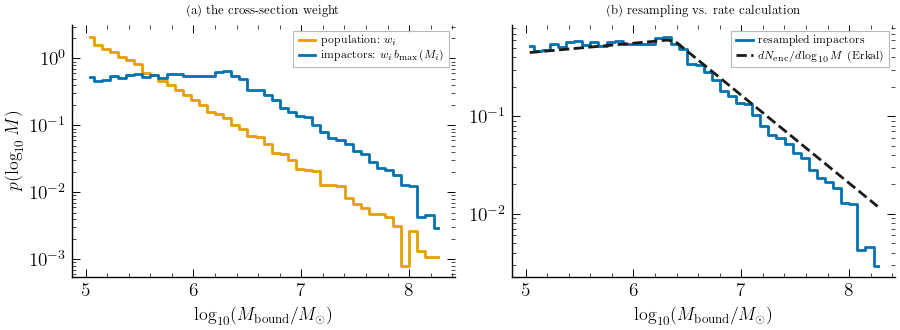

In [19]:
bins = np.linspace(*WINDOW, 45)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
widths = np.diff(bins)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5))

for d, lbl, col in ((u_draw, r"population: $w_i$", PALETTE[1]),
                    (w_draw, r"impactors: $w_i\,b_{\rm max}(M_i)$", PALETTE[0])):
    h, _ = np.histogram(np.log10(d["m_bound"]), bins=bins, density=True)
    axes[0].step(bin_centers, h, where="mid", lw=2, color=col, label=lbl)
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
axes[0].set_ylabel(r"$p(\log_{10}M)$")
axes[0].legend(fontsize=8)
axes[0].set_title("(a) the cross-section weight", fontsize=9)

h_w, _ = np.histogram(np.log10(w_draw["m_bound"]), bins=bins, density=True)
dN = np.asarray(rates.dN_dlog10M(jnp.asarray(bin_centers)))
dN_pdf = dN / np.sum(dN * widths)

axes[1].step(bin_centers, h_w, where="mid", lw=2, color=PALETTE[0],
             label="resampled impactors")
axes[1].plot(bin_centers, dN_pdf, lw=2, ls="--", color=INK,
             label=r"$dN_{\rm enc}/d\log_{10}M$ (Erkal)")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
axes[1].legend(fontsize=8)
axes[1].set_title("(b) resampling vs. rate calculation", fontsize=9)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()

ok = h_w > 0
print("resampled / Erkal ratio over the window: "
      f"median {np.median(h_w[ok] / dN_pdf[ok]):.3f}, "
      f"range {np.min(h_w[ok] / dN_pdf[ok]):.3f}-{np.max(h_w[ok] / dN_pdf[ok]):.3f}")

The two track each other over the bulk of the window. They are not required to agree
exactly: the dashed curve assumes a pure $dN/dM \propto M^{-1.9}$ bound-mass function,
while the histogram inherits pyHalo's actual one, which departs from a power law near the
window edges. If you need better agreement, the honest fix is to renormalize the Erkal
parameters to the pyHalo population, not to reweight the draw.

## 4.6 Placing the impacts

`ImpactGenerator` puts each impactor on the stream: a $\phi_1$ location, an impact time,
an impact parameter and a relative velocity, converted to a Cartesian fly-by. Two things
come from the rate side:

- `cat.b_bounds` — each impactor's own $b_{\rm max}$ as its ceiling, already in the
  `(2, N)` orientation `ImpactGenerator` indexes.
- `rates.nsub_along_orbit()` — so impact times are sampled from
  $p(t) \propto l(t)\,n_{\rm sub}(r(t))$ rather than from the stream length alone.

In [20]:
cat = catalogs["CDM"]
nsub_times, nsub_vals = model_rates["CDM"].nsub_along_orbit()

ImpactGen = ImpactGenerator(
    pot=pot,
    tobs=0.0,
    stream=stream,
    stream_phi1=phi1_model,
    phi1_bounds=[-80.0, 20.0],
    tImpactBounds=[-t_age, 0.0],
    phi1window=1.5,
    NumImpacts=len(cat),
    bImpact_bounds=cat.b_bounds,
    stripping_times=jnp.hstack([ts[:-1], ts[:-1]]),
    prog_today=prog_wtoday,
    nsub_times=nsub_times,
    nsub_vals=nsub_vals,
    seednum=100,
)

ImpactDict = ImpactGen.get_subhalo_ImpactParams()
cart = ImpactDict["CartesianImpactParams"]
imp = ImpactDict["ImpactFrameParams"]
print(f"{len(cat)} impacts;  cartesian params {cart.shape}")

107 impacts;  cartesian params (107, 6)


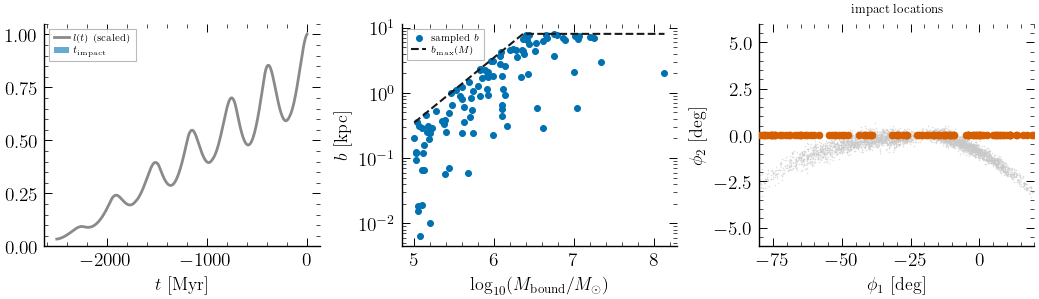

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2))

osc = ImpactGen.length_osc
axes[0].plot(osc["ts"], osc["length_func"] / float(jnp.max(osc["length_func"])),
             lw=2, color=MUTED, label=r"$l(t)$ (scaled)")
axes[0].hist(np.asarray(imp["tImpact"]), bins=20, density=True, alpha=0.6,
             color=PALETTE[0], label=r"$t_{\rm impact}$")
axes[0].set_xlabel(r"$t$ [Myr]")
axes[0].legend(fontsize=7)

order = np.argsort(cat["m_bound"])
axes[1].scatter(np.log10(cat["m_bound"]), np.asarray(imp["bImpact"]),
                s=18, color=PALETTE[0], label="sampled $b$")
axes[1].plot(np.log10(cat["m_bound"][order]), cat["b_max"][order],
             lw=1.5, ls="--", color=INK, label=r"$b_{\rm max}(M)$")
axes[1].set_yscale("log")
axes[1].set_xlabel(r"$\log_{10}(M_{\rm bound}/M_\odot)$")
axes[1].set_ylabel(r"$b$ [kpc]")
axes[1].legend(fontsize=7)

axes[2].scatter(phi1_model, phi2_model, s=0.05, color="#c8c8c8", rasterized=True)
axes[2].scatter(np.asarray(imp["phi1_samples"]), np.zeros(len(cat)),
                s=22, color=PALETTE[3], zorder=3)
axes[2].set_xlim(-80, 20)
axes[2].set_ylim(-6, 6)
axes[2].set_xlabel(r"$\phi_1$ [deg]")
axes[2].set_ylabel(r"$\phi_2$ [deg]")
axes[2].set_title("impact locations", fontsize=9)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()